In [7]:
import pandas as pd

df = pd.read_csv('job_data_merged_1.csv')
print(df.shape)
print(df.columns)
print(df.columns.tolist())

(1095, 6)
Index(['Unnamed: 0', 'Category', 'Workplace', 'Location', 'Department',
       'Type'],
      dtype='object')
['Unnamed: 0', 'Category', 'Workplace', 'Location', 'Department', 'Type']


In [19]:
import matplotlib.pyplot as plt

#check missing value
print("missing value")
print(df.isnull().sum())
print()

#what categories exict
print("job categories")
print(df['Category'].value_counts())

missing value
Unnamed: 0      0
Category        0
Workplace      56
Location       68
Department    166
Type          169
dtype: int64

job categories
Category
UI/UX                 191
Data Scientist        190
Software Developer    189
HR                    180
Business Analyst      175
Cloud                 170
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Fill missing values
df_clean = df.fillna('Unknown')

# Combine text features into one string
df_clean['features'] = (df_clean['Workplace'] + ' ' + 
                        df_clean['Location'] + ' ' + 
                        df_clean['Department'] + ' ' + 
                        df_clean['Type'])

from sklearn.feature_extraction.text import TfidfVectorizer

X = df_clean['features']
y = df_clean['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

  Business Analyst       0.82      0.51      0.63        35
             Cloud       0.47      0.41      0.44        34
    Data Scientist       0.54      0.55      0.55        38
                HR       0.75      0.75      0.75        36
Software Developer       0.50      0.76      0.60        38
             UI/UX       0.65      0.58      0.61        38

          accuracy                           0.60       219
         macro avg       0.62      0.60      0.60       219
      weighted avg       0.62      0.60      0.60       219



In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Try Logistic Regression instead of Random Forest
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000)),
    ('clf', LogisticRegression(max_iter=1000, C=5.0))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

f1_rf = f1_score(y_test, y_pred, average='macro')
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
print(f"Random Forest macro F1:      {f1_rf:.3f}")
print(f"Logistic Regression macro F1: {f1_lr:.3f}")

                    precision    recall  f1-score   support

  Business Analyst       0.70      0.66      0.68        35
             Cloud       0.48      0.41      0.44        34
    Data Scientist       0.49      0.53      0.51        38
                HR       0.90      0.78      0.84        36
Software Developer       0.50      0.66      0.57        38
             UI/UX       0.63      0.58      0.60        38

          accuracy                           0.60       219
         macro avg       0.62      0.60      0.61       219
      weighted avg       0.62      0.60      0.61       219

Random Forest macro F1:      0.597
Logistic Regression macro F1: 0.606


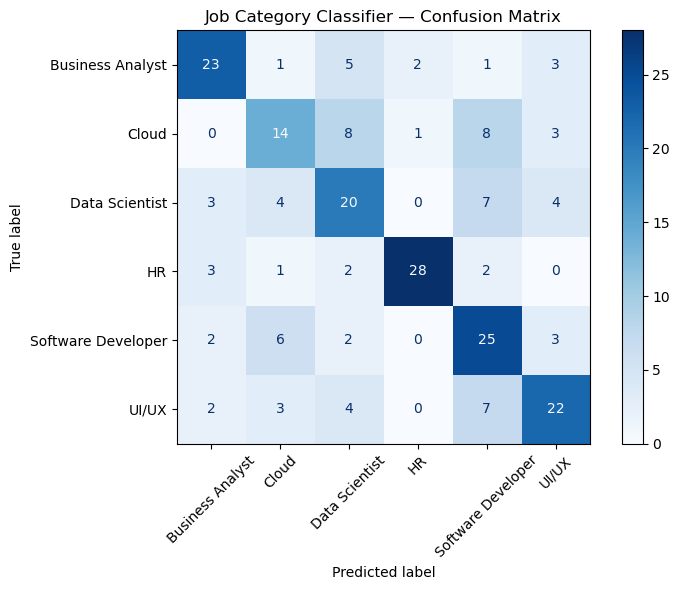

Saved to confusion_matrix.png


In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_lr,
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)

ax.set_title('Job Category Classifier — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("Saved to confusion_matrix.png")

In [25]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training data...")
X_train_emb = embedder.encode(X_train.tolist(), show_progress_bar=True)

print("Encoding test data...")
X_test_emb = embedder.encode(X_test.tolist(), show_progress_bar=True)

print("Done! Shape:", X_train_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding training data...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Encoding test data...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Done! Shape: (876, 384)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

clf_emb = LogisticRegression(max_iter=1000, C=5.0)
clf_emb.fit(X_train_emb, y_train)

y_pred_emb = clf_emb.predict(X_test_emb)

print(classification_report(y_test, y_pred_emb))

f1_tfidf = f1_score(y_test, y_pred_lr, average='macro')
f1_emb   = f1_score(y_test, y_pred_emb, average='macro')

print(f"TF-IDF + Logistic Regression:        {f1_tfidf:.3f}")
print(f"Sentence Transformer + LR:           {f1_emb:.3f}")
print(f"Improvement:                        +{f1_emb - f1_tfidf:.3f}")

                    precision    recall  f1-score   support

  Business Analyst       0.52      0.46      0.48        35
             Cloud       0.41      0.35      0.38        34
    Data Scientist       0.41      0.47      0.44        38
                HR       0.69      0.67      0.68        36
Software Developer       0.40      0.50      0.44        38
             UI/UX       0.50      0.42      0.46        38

          accuracy                           0.48       219
         macro avg       0.49      0.48      0.48       219
      weighted avg       0.49      0.48      0.48       219

TF-IDF + Logistic Regression:        0.606
Sentence Transformer + LR:           0.480
Improvement:                        +-0.126


In [27]:
import joblib

joblib.dump(pipeline_lr, 'best_model.pkl')
print("Model saved as best_model.pkl")

# Also save the label info
import json
categories = sorted(y.unique().tolist())
with open('categories.json', 'w') as f:
    json.dump(categories, f)
print("Categories saved:", categories)

Model saved as best_model.pkl
Categories saved: ['Business Analyst', 'Cloud', 'Data Scientist', 'HR', 'Software Developer', 'UI/UX']
